In [1]:
import numpy as np 

import sys
sys.path.insert(0, '/home/dabin/code/ichun_opto')

from simulate_data import wilson_cowan_model, wilson_cowan_slow_inhibition_model, lin_model
import matplotlib.pyplot as plt

In [2]:
data_dict = {}

In [3]:
# p26 : times considered : -50ms to 600ms. I suspect stimulus was shown at 0ms
DT = 1/30 # 1/30ms
N_TIMES_MS = 650
N_TIMES = int(N_TIMES_MS / DT)
STIM_ONSET_MS = 50 
STIM_DUR_MS = 2 # one of 1, 2, 4

STIM_ONSET = int(STIM_ONSET_MS / DT)
STIM_DUR = int(STIM_DUR_MS / DT)

H = DT / 1000 # in ms 

# Wilson-Cowan model parameters 
# p23 of paper 
parameters = {
    'tau_E' : 0.0011, # time constant for excitatory population
    'tau_I' : 0.0065, # time constant for inhibitory population
    'W_EE' : 0.0396,  # weight of excitatory to excitatory connections
    'W_IE' : 0.0277,  # weight of inhibitory to excitatory connections
    'W_EI' : 0.0074,  # weight of excitatory to inhibitory connections
    'W_II' : 0.0014,  # weight of inhibitory to inhibitory connections
    'E_max' : 29.5,
    'I_max' : 39.9,
    'C_E' : 0.0018,
    'C_I' : 0.0134,
    'XE' : 3.51, # input value is learnt as a parameter 
    'XI' : 1.26 # input value is learnt as a parameter
}


# create an np.narray of tuples that are both zero 
stimuli = np.zeros((N_TIMES, 2)) 
stimuli[STIM_ONSET:STIM_ONSET+STIM_DUR, 0] = 1 # stimulus to E population 
# stimuli[STIM_ONSET:STIM_ONSET+STIM_DUR, 1] = 1 # stimulus to I population

# Hard code initial_state values for discovery 
initial_state = {
    'E' : 1.0,
    'I' : 1.0,
}

data = wilson_cowan_model(initial_state, parameters, stimuli, N_TIMES, h=H) 
data_dict['WC'] = data


In [4]:
# p26 : times considered : -50ms to 600ms. I suspect stimulus was shown at 0ms
DT = 1/30 # 1/30ms
N_TIMES_MS = 650
N_TIMES = int(N_TIMES_MS / DT)
STIM_ONSET_MS = 50 
STIM_DUR_MS = 2 # one of 1, 2, 4

STIM_ONSET = int(STIM_ONSET_MS / DT)
STIM_DUR = int(STIM_DUR_MS / DT)

H = DT / 1000 # in ms 

# Wilson-Cowan with slow inhibition model parameters - p23 of paper 
parameters = {
    'tau_E' : 0.0011, # time constant for excitatory population
    'tau_I' : 0.0026, # time constant for inhibitory population
    'W_EE' : 0.0101,  # weight of excitatory to excitatory connections
    'W_IE' : 0.0098,  # weight of inhibitory to excitatory connections
    'W_EI' : 0.0012,  # weight of excitatory to inhibitory connections
    'W_II' : 0.0020,  # weight of inhibitory to inhibitory connections
    'E_max' : 115.6,
    'I_max' : 113.8,
    'C_E' : 0.0014,
    'C_I' : 0.0030,
    'tau_S' : 0.0586,
    'W_ES' : 0.0018,
    'W_IS' : 0.0016,
    'XE' : 1.64,
    'XI' : 0.16
}

# create an np.narray of tuples that are both zero 
stimuli = np.zeros((N_TIMES, 2)) 
stimuli[STIM_ONSET:STIM_ONSET+STIM_DUR, 0] = 1 # stimulus to E population 
# stimuli[STIM_ONSET:STIM_ONSET+STIM_DUR, 1] = 1 # stimulus to I population

# Hard code initial_state values for discovery 
initial_state = {
    'E' : 1.0,     
    'I' : 1.0,
    'S' : 1.0
}

data = wilson_cowan_slow_inhibition_model(initial_state, parameters, stimuli, N_TIMES, h=H) 
data_dict['WC_SI'] = data


In [5]:
# p26 : times considered : -50ms to 600ms. I suspect stimulus was shown at 0ms
DT = 1/30 # 1/30ms
N_TIMES_MS = 650
N_TIMES = int(N_TIMES_MS / DT)
STIM_ONSET_MS = 50 
STIM_DUR_MS = 2 # one of 1, 2, 4

STIM_ONSET = int(STIM_ONSET_MS / DT)
STIM_DUR = int(STIM_DUR_MS / DT)

H = DT / 1000 # in ms 

# Lin's model parameters, p23 of paper 
parameters = {
    'tau_E' : 0.0032, # time constant for excitatory population
    'tau_I' : 0.0036, # time constant for inhibitory population
    'W_EE' : 0.0227,  # weight of excitatory to excitatory connections
    'W_IE' : 0.0132,  # weight of inhibitory to excitatory connections
    'W_EI' : 0.0038,  # weight of excitatory to inhibitory connections
    'W_II' : 0.0166,  # weight of inhibitory to inhibitory connections
    'E_max' : 42.91,
    'I_max' : 46.91,
    'C_E' : 0.0005,
    'C_I' : 0.0066,
    'tau_S' : 0.0676,
    'W_ES' : 0.0063,
    'W_IS' : 0.0088,
    'tau_B' : 0.0969,
    'tau_R' : 0.0147,
    'W_EL' : 0.0080,
    'W_IL' : 0.0211, 
    'W_LE' : 0.0508,
    'W_LB' : 0.1811,
    'W_LT' : 1.792, 
    'W_RE' : 0.0871,
    'W_RL' : 0.1355,
    'C_R' : 6.79,
    'L_max' : 10.35,
    'C_L' : 0.057,
    'XE' : 3.89,
    'XI' : 0.63
}

# create an np.narray of tuples that are both zero 
stimuli = np.zeros((N_TIMES, 2))
stimuli[STIM_ONSET:STIM_ONSET+STIM_DUR, 0] = 1 # stimulus to E population 
# stimuli[STIM_ONSET:STIM_ONSET+STIM_DUR, 1] = 1 # stimulus to I population

# Hard code initial_state values for discovery 
initial_state = {
    'E' : 1.0, 
    'I' : 1.0,
    'S' : 1.0, 
    'L' : 1.0,
    'R' : 0.0, 
    'B' : 0.0,
    'T' : 0.0,
}

data = lin_model(initial_state, parameters, stimuli, N_TIMES, h=H) 
data_dict['Lin'] = data

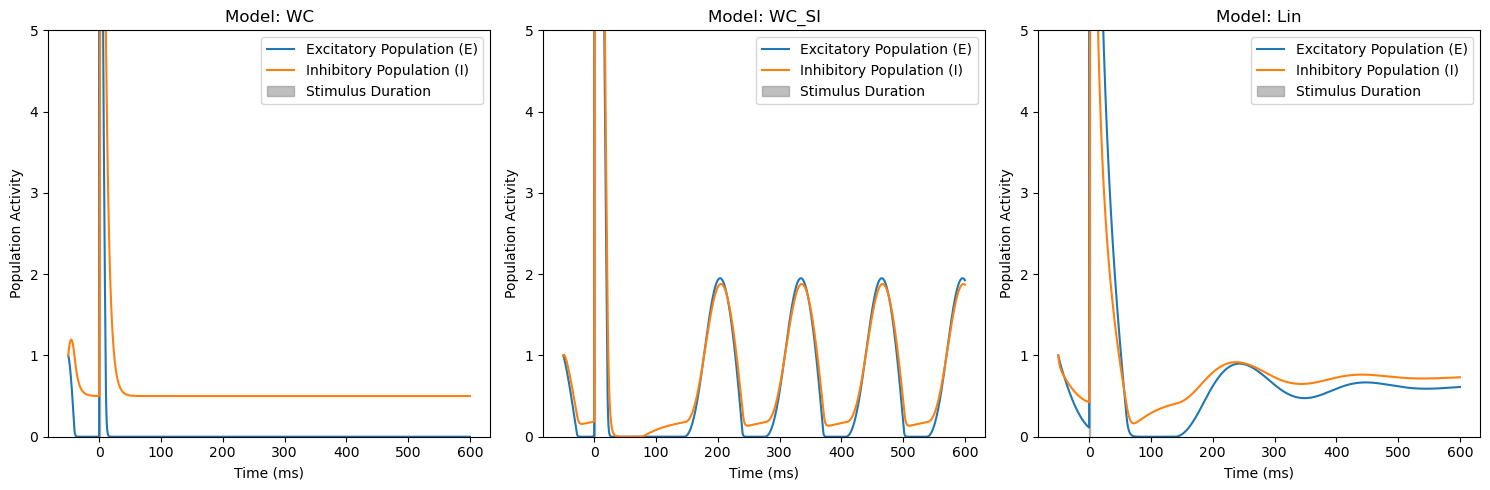

In [6]:
model_names = ['WC', 'WC_SI', 'Lin']
n_models = len(model_names)

fig, axs = plt.subplots(1, n_models, figsize=(5 * n_models, 5))

x = np.arange(N_TIMES) * DT - 50
for i, model_name in enumerate(model_names):
    data = data_dict[model_name]
    ax = axs[i]

    ax.plot(x, data[:, 0], label='Excitatory Population (E)')
    ax.plot(x, data[:, 1], label='Inhibitory Population (I)')
    # shade the stim duration vertically
    ax.axvspan(STIM_ONSET_MS - 50, STIM_ONSET_MS + STIM_DUR_MS - 50, color='gray', alpha=0.5, label='Stimulus Duration')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Population Activity')
    ax.set_ylim(0, 5)
    ax.legend()
    ax.set_title(f'Model: {model_name}')
plt.tight_layout()
plt.show()

Generate data for multiple cells (i.e. multiple sets of params) with multiple repeats 
Here, each 'sample' would correspond to one animal. 

We're only going to consider single pulse stimuli of either E or I -- i.e. n_stim_conditions = 2. 

Let n_repeats = 12

Output
- response array of shape (n_samples, n_stim_conditions, n_repeats, n_time_bins, 2)
- stimuli of shape (n_stim_conditions, n_time_bins, 2) # last dim : (E_pulse, I_pulse)
- parameters array of shape (n_samples, n_params)
- initial conditions of shape (n_samples, n_stim_conditions, n_repeats, n_state_variables)

In [7]:
def generate_parameters(param_medians, param_mad, n_samples, random_seed=0):
    """Generate (n_samples, n_params) array of parameters sampled from a uniform distribution defined by the median and MAD of each parameter."""
    rng = np.random.default_rng(random_seed)
    parameters = np.zeros((n_samples, len(param_medians)))
    for sample_idx in range(n_samples):
        for param_idx, (param_name, median) in enumerate(param_medians.items()):
            mad = param_mad[param_name]
            low = median - mad
            high = median + mad
            parameters[sample_idx, param_idx] = rng.uniform(low, high)
    return parameters

def add_noise(mean, random_seed=0):
    """Add signal dependent noise for each time bin
    Noise std is proportional to the sqrt of the mean with a proportionality constant of 0.1. The noise is sampled from a normal distribution with mean 0 and std = 0.1 * sqrt(mean). The noise is then added to the mean to generate the noisy signal.

    Parameters
    ----------
    mean : (n_times, 2)
        Mean response of excitatory and inhibitory pouplations with shape (n_times, 2).

    Returns
    -------
    np.ndarray
        Noisy signal with shape (n_times, 2).
    """    
    rng = np.random.default_rng(random_seed)
    noise_std = 0.1 * np.sqrt(mean)
    noisee = rng.normal(0, noise_std, size=mean.shape)
    noisy_signal = mean + noisee
    return noisy_signal

In [25]:
# Simulate Wilson-Cowan model with multiple samples (animals)
N_SAMPLES = 8
N_REPEATS = 12 

DT = 1/30 # 1/30ms
N_TIMES_MS = 650
N_TIMES = int(N_TIMES_MS / DT)
STIM_ONSET_MS = 50 
STIM_DUR_MS = 2 # one of 1, 2, 4

STIM_ONSET = int(STIM_ONSET_MS / DT)
STIM_DUR = int(STIM_DUR_MS / DT)

H = DT / 1000 # in ms 

PARAM_MEDIAN = {
    'tau_E' : 0.0011, # time constant for excitatory population
    'tau_I' : 0.0065, # time constant for inhibitory population
    'W_EE' : 0.0396,  # weight of excitatory to excitatory connections
    'W_IE' : 0.0277,  # weight of inhibitory to excitatory connections
    'W_EI' : 0.0074,  # weight of excitatory to inhibitory connections
    'W_II' : 0.0014,  # weight of inhibitory to inhibitory connections
    'E_max' : 29.5,
    'I_max' : 39.9,
    'C_E' : 0.0018,
    'C_I' : 0.0134,
    'XE' : 3.51,
    'XI' : 1.26
}

PARAM_MAD = {
    'tau_E' : 0.0002, 
    'tau_I' : 0.0019, 
    'W_EE' : 0.0162,
    'W_IE' : 0.0111,
    'W_EI' : 0.0033,
    'W_II' : 0.0115,
    'E_max' : 13.1,
    'I_max' : 16.4,
    'C_E' : 0.0016,
    'C_I' : 0.0115,
    'XE' : 2.10,
    'XI' : 0.86,
}

params = generate_parameters(PARAM_MEDIAN, PARAM_MAD, N_SAMPLES)

# create an np.narray of tuples that are both zero 
exc_stimuli = np.zeros((N_TIMES, 2)) 
exc_stimuli[STIM_ONSET:STIM_ONSET+STIM_DUR, 0] = 1 # stimulus to E population 

inh_stimuli = np.zeros((N_TIMES, 2)) 
inh_stimuli[STIM_ONSET:STIM_ONSET+STIM_DUR, 1] = 1 # stimulus to I population

stimuli = np.stack([exc_stimuli, inh_stimuli], axis=0)

# Hard code initial_state values for discovery 
initial_state = {
    'E' : 1.0,
    'I' : 1.0,
}

# - response array of shape (n_samples, n_stim_conditions = 2,  n_repeats = 12, n_time_bins, 2)
# - stimuli of shape (n_stim_conditions=2, n_time_bins, 2)
# - parameters array of shape (n_samples, n_params)

data = np.zeros((N_SAMPLES, 2, N_REPEATS, N_TIMES, 2)) # 2 for E and I
param_names = list(PARAM_MEDIAN.keys())          # fixes the value→name mapping
for i, p in enumerate(params):
    p = dict(zip(param_names, p))                 # array row -> dict the model expects
    for j, stim in enumerate(stimuli):
        activity = wilson_cowan_model(initial_state, p, stim, N_TIMES, h=H)
        for k in range(N_REPEATS):
            data[i, j, k, :, :] = add_noise(activity, random_seed=i*N_REPEATS+k)

In [29]:
print(f"data shape: {data.shape}")
print(f"params shape: {params.shape}")
print(f"stimuli shape: {stimuli.shape}")

# save as an npz file 
np.savez('simulated_data.npz', data=data, params=params, stimuli=stimuli)

data shape: (8, 2, 12, 19500, 2)
params shape: (8, 12)
stimuli shape: (2, 19500, 2)


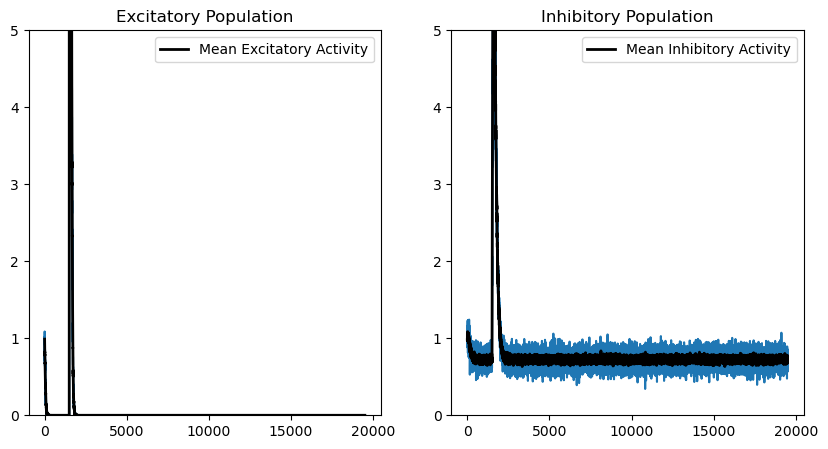

In [27]:
# data has shape (n_samples, n_stim_conditions=2, n_repeats=12, n_time_bins, 2)
sample_idx = 0 
stim_condition = 0 
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# for repeat_idx in range(N_REPEATS):
for repeat_idx in [0]:
    axs[0].plot(data[sample_idx, stim_condition, repeat_idx, :, 0])
    axs[1].plot(data[sample_idx, stim_condition, repeat_idx, :, 1])
mean_exc = np.mean(data[sample_idx, stim_condition, :, :, 0], axis=0)
mean_inh = np.mean(data[sample_idx, stim_condition, :, :, 1], axis=0)
axs[0].plot(mean_exc, color='black', linewidth=2, label='Mean Excitatory Activity')
axs[1].plot(mean_inh, color='black', linewidth=2, label='Mean Inhibitory Activity')
axs[0].legend()
axs[1].legend()
axs[0].set_title('Excitatory Population')
axs[1].set_title('Inhibitory Population')
axs[0].set_ylim(0, 5)
axs[1].set_ylim(0, 5)
plt.show()

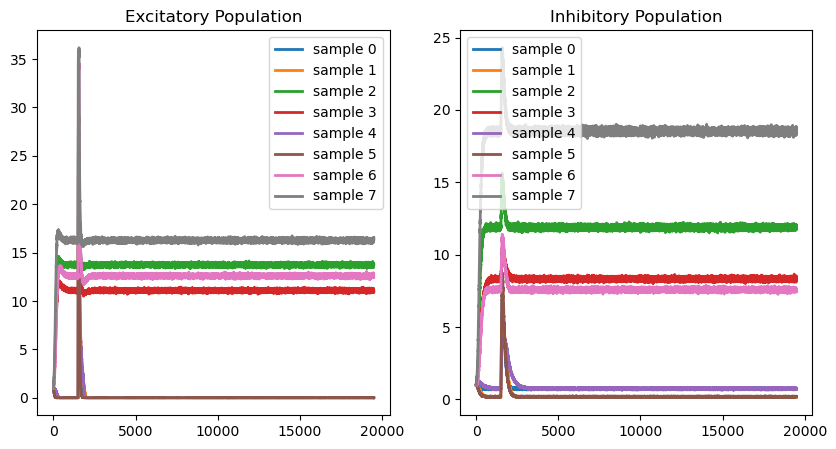

In [28]:
# data has shape (n_samples, n_stim_conditions=2, n_repeats=12, n_time_bins, 2)

stim_condition = 0 
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for sample_idx in range(data.shape[0]):
    mean_exc = np.mean(data[sample_idx, stim_condition, :, :, 0], axis=0)
    mean_inh = np.mean(data[sample_idx, stim_condition, :, :, 1], axis=0)

    axs[0].plot(mean_exc, linewidth=2, label=f'sample {sample_idx}')
    axs[1].plot(mean_inh, linewidth=2, label=f'sample {sample_idx}')
axs[0].legend()
axs[1].legend()
axs[0].set_title('Excitatory Population')
axs[1].set_title('Inhibitory Population')
plt.show()